===
Original Data: ===
        Date  Temperature  Humidity  WindSpeed  Precipitation Condition
0 2024-01-01           14        62          8              0     Sunny
1 2024-01-02           16        58         10              0     Sunny
2 2024-01-03           12        71         12              2      Rain
3 2024-01-04           13        68          9              0    Cloudy
4 2024-01-05           15        64          8              0     Sunny
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           30 non-null     datetime64[ns]
 1   Temperature    30 non-null     int64         
 2   Humidity       30 non-null     int64         
 3   WindSpeed      30 non-null     int64         
 4   Precipitation  30 non-null     int64         
 5   Condition      30 non-null     object        
dtypes: datetime64[ns](1), int64(4)

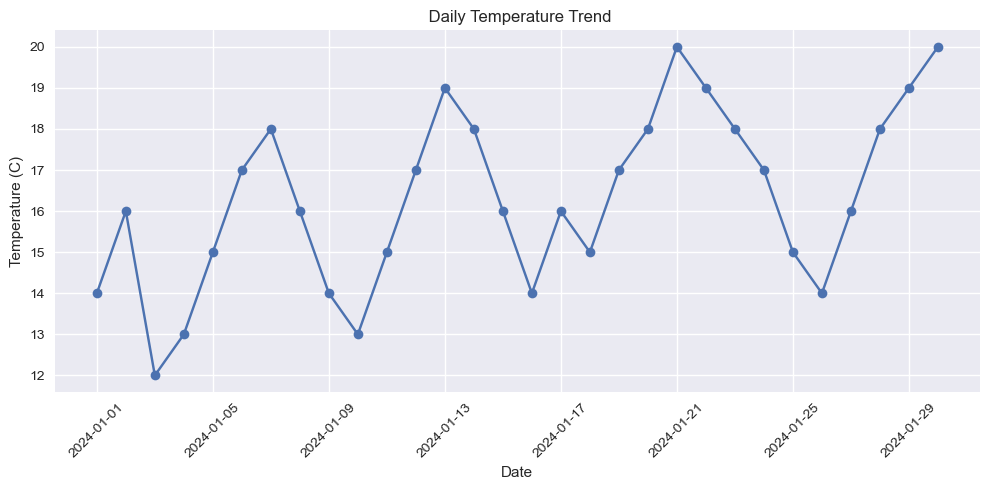

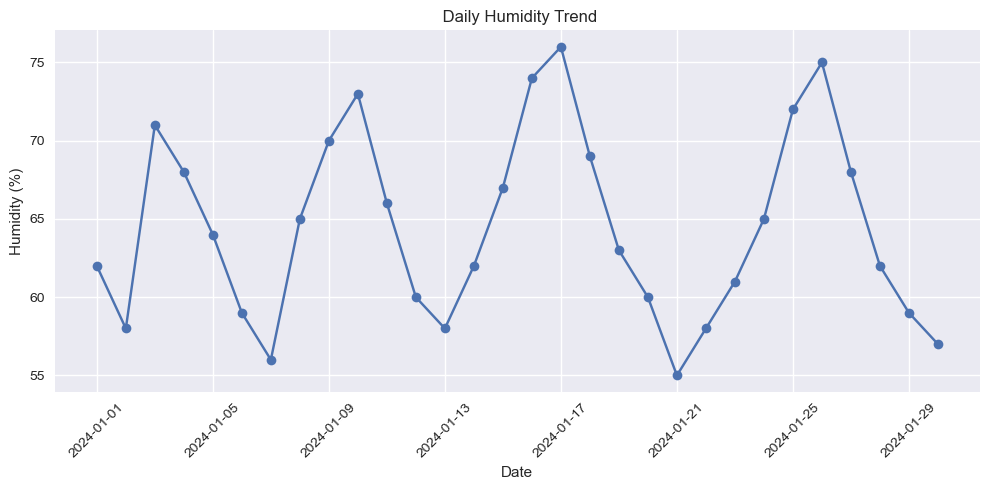

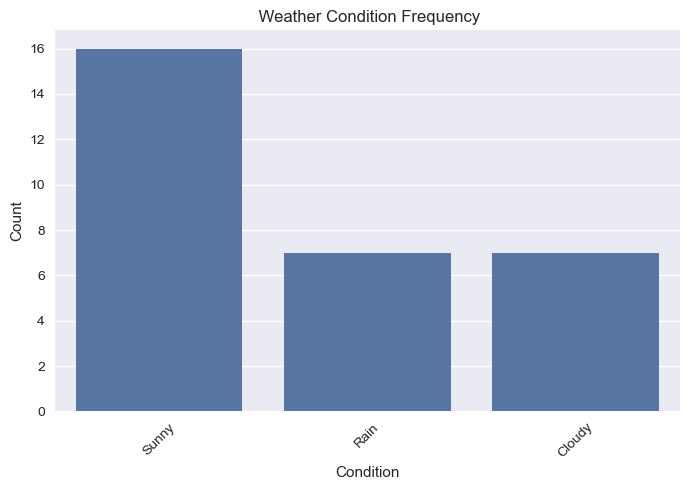

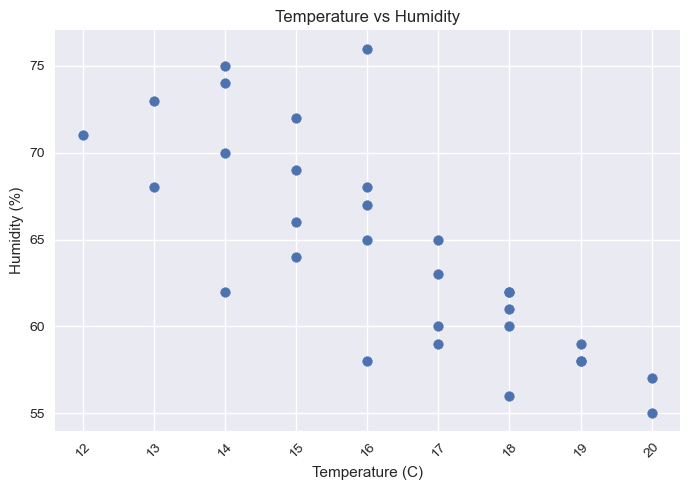

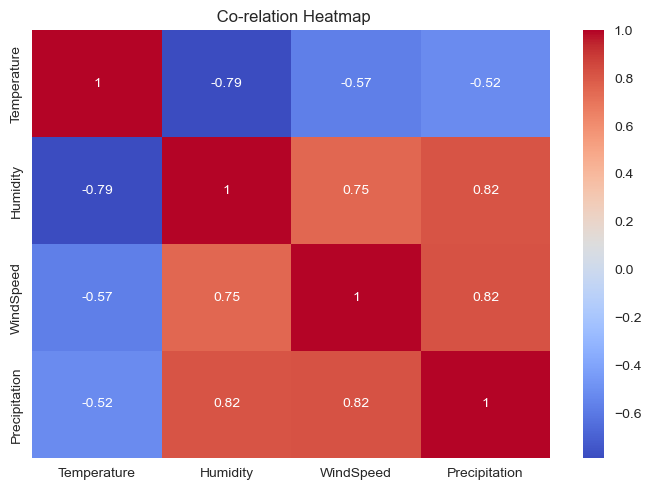

In [14]:
# Step 1 - Importing Libraries 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

# For Good looking plots 
plt.style.use("seaborn-v0_8")

# Step 2 - Load File 
file_path = r"C:\Users\princ\Desktop\AI_Programming_Project\Weather_Data.csv"
df = pd.read_csv(file_path)

# Step 3 - Display original Data 
 
# Convert Date column to datetime 
df['Date'] = pd.to_datetime(df['Date'])

print("===\nOriginal Data: ===")
print(df.head())
print(df.info())
print(df.describe())

# Step 4 - Handling missing Values 
df.fillna({
    "Precipitation": 0,
    "WindSpeed": df["WindSpeed"].mean(),
    "Humidity": df["Humidity"].mean()
}, inplace=True)

# Step 5 - Add Mising Columns (Month, Day)

df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

# Step 6 - Data Analysis 
avg_Temp = df["Temperature"].mean()
avg_humidity = df["Humidity"].mean()
print(f'Average Temperature: {avg_Temp:.2f} C')
print(f'Average Humidity: {avg_humidity:.2f} %')


condition_count = df["Condition"].value_counts
print("\n===Condition Frequency===")
print(condition_count)

# Step 7 - Visualization 

# Temperature Trend 
plt.figure(figsize = (10,5))
plt.plot(df["Date"], df["Temperature"], marker = 'o')
plt.title(" Daily Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# Humidity Trend 
plt.figure(figsize = (10,5))
plt.plot(df["Date"], df["Humidity"], marker = 'o')
plt.title(" Daily Humidity Trend")
plt.xlabel("Date")
plt.ylabel("Humidity (%)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# Condition Frequency
plt.figure(figsize = (7,5))
sns.countplot(x="Condition", data=df)
plt.title(" Weather Condition Frequency")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# Temperature vs Humidity (Scatter plot)
plt.figure(figsize = (7,5))
plt.scatter(df["Temperature"], df["Humidity"])
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (C)")
plt.ylabel("Humidity (%)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# Co-relation Heatmap
plt.figure(figsize = (7,5))
sns.heatmap(df[["Temperature", "Humidity", "WindSpeed", "Precipitation"]].corr(), annot = True, cmap = "coolwarm" )
plt.title(" Co-relation Heatmap")
plt.tight_layout()
plt.show()

